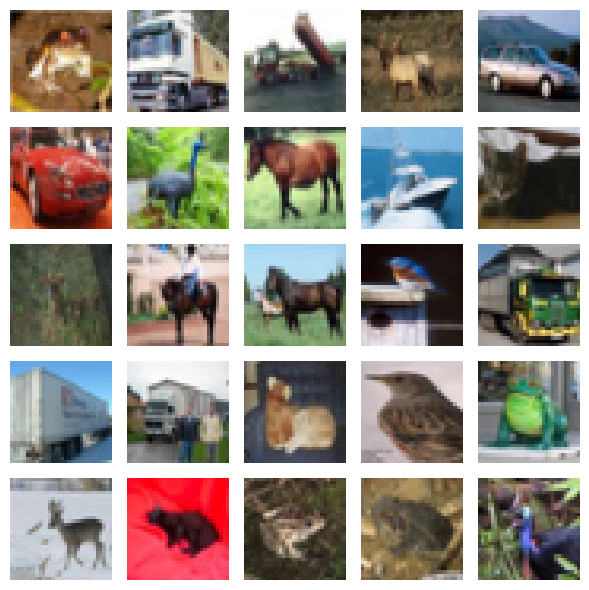

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.010800153..1.132977].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.017718256..1.145905].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.1311979..0.99897575].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.114887804..0.9226053].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.014149725..0.9937601].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.01245001..1.0669283].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.

Original shape:  (25, 3072)
PCA shape:  (25, 10)
PCA result:
 [[-6.85300064e+00  1.85264337e+00  2.17655611e+00  4.32208252e+00
  -2.50483847e+00  3.23519498e-01  2.03494263e+00  4.16138470e-01
  -2.59615755e+00 -1.24301434e+00]
 [ 1.64976883e+00  5.95560265e+00 -2.22846699e+00  7.23952055e+00
  -4.37016058e+00  7.20660329e-01 -2.23846173e+00 -2.33195329e+00
   6.85985661e+00  2.19437861e+00]
 [ 1.18758326e+01 -7.63593817e+00 -3.35274458e+00 -1.96137643e+00
  -2.92745781e+00  1.72934163e+00  1.42866981e+00  3.25563455e+00
  -6.74047232e-01 -2.29043221e+00]
 [-8.82461071e+00  3.94416273e-01 -1.76346421e+00  2.23082018e+00
  -7.36715019e-01  3.88618410e-01 -4.92283344e-01 -3.62719297e-01
  -2.57837272e+00  1.04079716e-01]
 [ 6.87934220e-01  4.61627662e-01 -6.45692444e+00  1.83286893e+00
   4.23493958e+00  6.08246231e+00  1.37421703e+00 -2.75070405e+00
   8.02970469e-01  2.40372252e+00]
 [-4.51570082e+00 -6.25397778e+00  2.02879429e+00  4.51766109e+00
  -1.36525834e+00 -2.00709677e+00  1.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07927358..0.9811734].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.02010566..0.8505771].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.07920846..1.1496637].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.06870863..0.89839184].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.21429437..1.0042235].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.14398992..1.1158988].


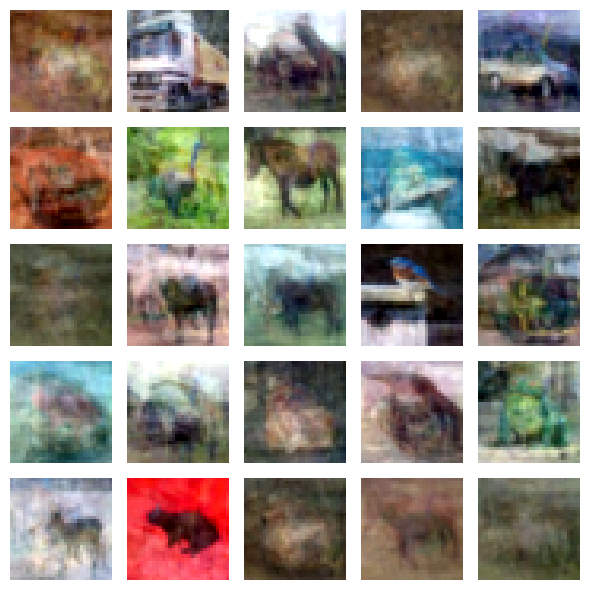

In [1]:
#########################################################
#   JUST TESTING PCA AND LEARNING HOW TO USE MATPLOTLIB #
#########################################################

from torchvision import datasets, transforms
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

transform = transforms.ToTensor()

cifar10 = datasets.CIFAR10(
    root="../data/cifar10",
    train=True,
    download=True,
    transform=transform
)

images=[]

plt.figure(figsize=(6,6))

for i in range(25): #load 25 images
    image, label=cifar10[i]
    img_array=image.numpy()
    img_array=img_array.transpose(1,2,0)
    images.append(img_array)
    
    plt.subplot(5, 5, i+1)
    plt.imshow(img_array)
    plt.axis('off')
    
plt.tight_layout()
plt.show()

images=np.array(images)  
N, H, W, C=images.shape
x=images.reshape(N, -1)

pca=PCA(n_components=10)
x_pca=pca.fit_transform(x)

print("Original shape: ", x.shape)
print("PCA shape: ", x_pca.shape)
print("PCA result:\n", x_pca)

reconstructed=pca.inverse_transform(x_pca)
r_images=reconstructed.reshape(N, 32, 32, 3)

plt.figure(figsize=(6,6))

for i in range (25):
    plt.subplot(5, 5, i+1)
    plt.imshow(r_images[i], interpolation='nearest')
    plt.axis('off')
    
plt.tight_layout()
plt.show()


